# LLM Explanation Layer - Faithfulness Evaluation

Runs the faithfulness experiment on 200 flagged test-set transactions:
1. Load model + compute SHAP values
2. Generate explanations with prompt v1 (unconstrained) and v2 (constrained)
3. Score faithfulness for both versions
4. Compare: direction accuracy, value accuracy, hallucination rate
5. Manual inspection of failure cases

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import mlflow
import mlflow.lightgbm
import matplotlib.pyplot as plt
import json

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src.models.shap_utils import (
    build_explainer, compute_shap_values, get_feature_cols,
    top_k_features, explanation_contract,
)
from src.explainability.llm_explainer import generate_explanation
from src.explainability.faithfulness_eval import compute_faithfulness, evaluate_batch

MLFLOW_TRACKING_URI = f"sqlite:///{ROOT / 'mlflow' / 'mlruns.db'}"
DATA_PROCESSED = ROOT / "data" / "processed"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
print("Setup complete.")

Setup complete.


## 1. Load Model and Test Data

In [2]:
# Load the registered production model
client = mlflow.tracking.MlflowClient()
model_version = client.get_registered_model("anomaly-detector").latest_versions[0]
run_id = model_version.run_id

run = client.get_run(run_id)
threshold = float(run.data.tags.get("threshold", 0.5))

model = mlflow.lightgbm.load_model(f"runs:/{run_id}/model")
print(f"Loaded model from run {run_id}")
print(f"Operating threshold: {threshold:.4f}")

# Load test set
test_df = pd.read_parquet(DATA_PROCESSED / "features_test.parquet")
feature_cols = get_feature_cols(test_df)
X_test = test_df[feature_cols]
y_test = test_df["isFraud"]

print(f"Test set: {len(test_df):,} rows, {y_test.sum():,} actual fraud")

Loaded model from run 1ac30daf57a2423b95af530d4eb46d51
Operating threshold: 0.7566
Test set: 88,581 rows, 3,083 actual fraud


## 2. Sample 200 Flagged Transactions and Compute SHAP

In [3]:
N_EVAL = 50

# Score all test transactions
test_probs = model.predict_proba(X_test)[:, 1]
flagged_mask = test_probs >= threshold
flagged_idx = np.where(flagged_mask)[0]
print(f"Flagged transactions in test set: {len(flagged_idx):,} ({len(flagged_idx)/len(test_df)*100:.1f}%)")

# Sample 50 flagged transactions (same seed as run_faithfulness_eval.py)
rng = np.random.default_rng(42)
sample_idx = np.sort(rng.choice(flagged_idx, size=min(N_EVAL, len(flagged_idx)), replace=False))

X_sample = X_test.iloc[sample_idx]
scores_sample = test_probs[sample_idx]

print(f"Computing SHAP values for {len(sample_idx)} flagged transactions ...")
explainer = build_explainer(model)
shap_vals = compute_shap_values(explainer, X_sample)
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = float(base_value[1])

print(f"SHAP done. base_value={base_value:.4f}")

# Build top-3 feature dicts for each sample
eval_records = []
for i in range(len(sample_idx)):
    txn_id = int(test_df.iloc[sample_idx[i]]["TransactionID"]) if "TransactionID" in test_df.columns else int(sample_idx[i])
    top_feats = top_k_features(shap_vals[i], feature_cols, X_sample.iloc[i].values, k=3)
    eval_records.append({
        "transaction_id": txn_id,
        "score": float(scores_sample[i]),
        "top_features": top_feats,
    })

print(f"\nSample explanation contract (first record):")
print(json.dumps(eval_records[0], indent=2))

Flagged transactions in test set: 2,418 (2.7%)
Computing SHAP values for 50 flagged transactions ...


SHAP done. base_value=-3.5102

Sample explanation contract (first record):
{
  "transaction_id": 3495033,
  "score": 0.9482196886952102,
  "top_features": [
    {
      "feature": "C1",
      "shap_value": 2.4309,
      "feature_value": 41.0,
      "direction": "increases_risk"
    },
    {
      "feature": "card1",
      "shap_value": 1.3592,
      "feature_value": 0.0383,
      "direction": "increases_risk"
    },
    {
      "feature": "C4",
      "shap_value": 0.4397,
      "feature_value": 5.0,
      "direction": "increases_risk"
    }
  ]
}


/opt/anaconda3/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## 3. Load Pre-Generated Explanations

Explanations were generated via `src/explainability/run_faithfulness_eval.py` (50 transactions x 2 prompt versions).
Results are loaded from `data/processed/faithfulness_results.json`.

In [4]:
RESULTS_PATH = ROOT / "data" / "processed" / "faithfulness_results.json"

with open(RESULTS_PATH) as f:
    saved = json.load(f)

v1_results = saved["v1"]["results"]
v2_results = saved["v2"]["results"]

print(f"Loaded {len(v1_results)} v1 results and {len(v2_results)} v2 results")
print(f"\nSample v1 explanation (first record):")
print(f"  Score : {v1_results[0]['score']:.3f}")
print(f"  Top features: {[f['feature'] for f in v1_results[0]['top_features']]}")
print(f"  Explanation: {v1_results[0]['explanation']}")
print(f"\nSample v2 explanation (same transaction):")
print(f"  Explanation: {v2_results[0]['explanation']}")

Loaded 50 v1 results and 50 v2 results

Sample v1 explanation (first record):
  Score : 0.948
  Top features: ['C1', 'card1', 'C4']
  Explanation: This transaction was flagged due to an anomaly score of 0.95, indicating a high level of suspicious activity. The card1 value of 0.0383 is significantly lower than the C1 value of 41.0, which may indicate a discrepancy in the transaction data. This discrepancy contributed to the transaction's high anomaly score.

Sample v2 explanation (same transaction):
  Explanation: The transaction was flagged due to three contributing factors. The value of C1 was $41.00, which increased the fraud risk by 2.431 points. Additionally, the card1 feature had a value of 0.0383, and C4 had a value of 5.0, both of which also increased the fraud risk.


## 4. Faithfulness Scoring

In [5]:
v1_records = [{"explanation": r["explanation"], "top_features": r["top_features"]} for r in v1_results]
v2_records = [{"explanation": r["explanation"], "top_features": r["top_features"]} for r in v2_results]

v1_summary = evaluate_batch(v1_records, prompt_version="v1")
v2_summary = evaluate_batch(v2_records, prompt_version="v2")

print("=" * 55)
print(f"{'Metric':<35} {'v1':>8} {'v2':>8}")
print("=" * 55)

metrics = [
    ("mention_rate",           "mean_mention_rate"),
    ("direction_accuracy",     "mean_direction_accuracy"),
    ("value_accuracy",         "mean_value_accuracy"),
    ("hallucination_rate",     "hallucination_rate"),
    ("composite_faithfulness", "mean_composite_faithfulness"),
]

for label, key in metrics:
    v1_val = v1_summary.get(key)
    v2_val = v2_summary.get(key)
    v1_str = f"{v1_val:.3f}" if v1_val is not None else "  N/A"
    v2_str = f"{v2_val:.3f}" if v2_val is not None else "  N/A"
    print(f"  {label:<33} {v1_str:>8} {v2_str:>8}")

print("=" * 55)
print(f"\nNote: mention_rate for v2 is trivially ~1.0 by prompt design - not a signal.")
print(f"      The meaningful v2 metrics are direction_accuracy, value_accuracy, hallucination_rate.")

Metric                                    v1       v2
  mention_rate                         0.760    0.987
  direction_accuracy                   0.879    0.991
  value_accuracy                       0.740    0.993
  hallucination_rate                   0.160    0.040
  composite_faithfulness               0.160    0.733

Note: mention_rate for v2 is trivially ~1.0 by prompt design - not a signal.
      The meaningful v2 metrics are direction_accuracy, value_accuracy, hallucination_rate.


## 5. Visualise Results

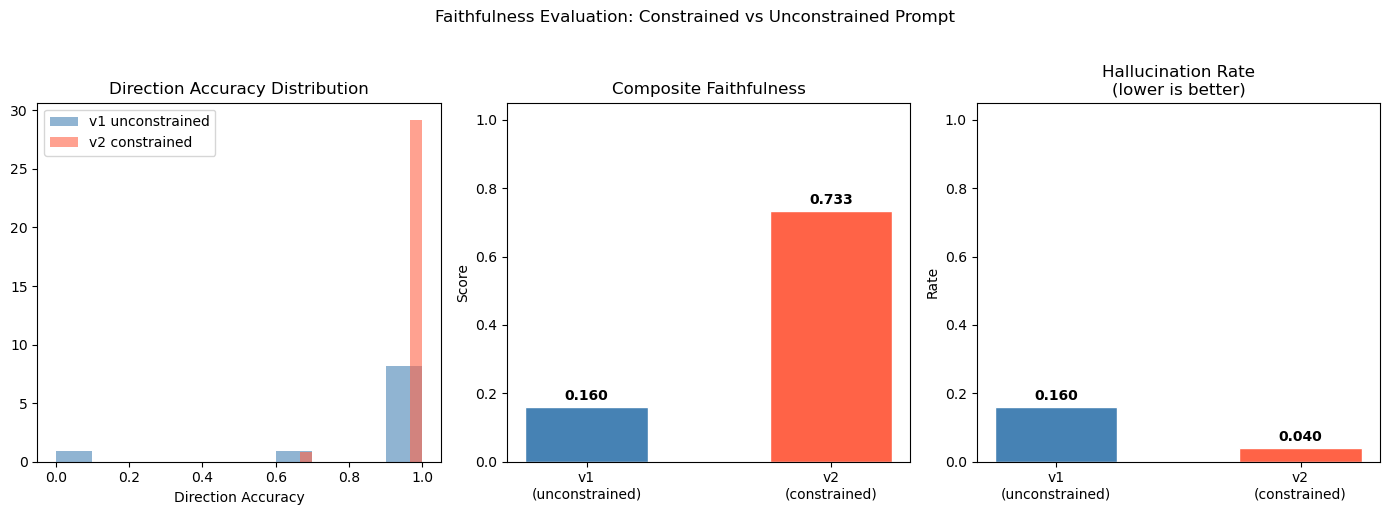

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# --- Direction accuracy distribution ---
v1_da = [r["direction_accuracy"] for r in v1_summary["individual"] if r["direction_accuracy"] is not None]
v2_da = [r["direction_accuracy"] for r in v2_summary["individual"] if r["direction_accuracy"] is not None]
axes[0].hist(v1_da, bins=10, alpha=0.6, color="steelblue", label="v1 unconstrained", density=True)
axes[0].hist(v2_da, bins=10, alpha=0.6, color="tomato", label="v2 constrained", density=True)
axes[0].set_title("Direction Accuracy Distribution")
axes[0].set_xlabel("Direction Accuracy")
axes[0].legend()

# --- Composite faithfulness bar comparison ---
labels = ["v1\n(unconstrained)", "v2\n(constrained)"]
values = [v1_summary["mean_composite_faithfulness"], v2_summary["mean_composite_faithfulness"]]
colors = ["steelblue", "tomato"]
bars = axes[1].bar(labels, values, color=colors, edgecolor="white", width=0.5)
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Composite Faithfulness")
axes[1].set_ylabel("Score")
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}",
                 ha="center", fontweight="bold")

# --- Hallucination rate ---
hall_vals = [v1_summary["hallucination_rate"], v2_summary["hallucination_rate"]]
bars2 = axes[2].bar(labels, hall_vals, color=colors, edgecolor="white", width=0.5)
axes[2].set_ylim(0, 1.05)
axes[2].set_title("Hallucination Rate\n(lower is better)")
axes[2].set_ylabel("Rate")
for bar, val in zip(bars2, hall_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}",
                 ha="center", fontweight="bold")

plt.suptitle("Faithfulness Evaluation: Constrained vs Unconstrained Prompt", y=1.02)
plt.tight_layout()
plt.show()

## 6. Manual Inspection - Failure Cases and Sample Explanations

In [7]:
# Show 3 side-by-side examples: v1 vs v2 for the same transaction
print("=" * 80)
print("SAMPLE EXPLANATIONS: v1 (unconstrained) vs v2 (constrained)")
print("=" * 80)

for i in range(min(3, len(v1_results))):
    rec = eval_records[i]
    v1_exp = v1_results[i]["explanation"]
    v2_exp = v2_results[i]["explanation"]

    print(f"\n--- Transaction {rec['transaction_id']} | Score: {rec['score']:.3f} ---")
    print(f"Top features:")
    for f in rec["top_features"]:
        print(f"  {f['feature']:30s} shap={f['shap_value']:+.3f}  val={f['feature_value']:.3f}  ({f['direction']})")

    print(f"\nv1 explanation:")
    print(f"  {v1_exp}")
    v1_faith = compute_faithfulness(v1_exp, rec["top_features"], "v1")
    print(f"  -> mention={v1_faith['mention_rate']:.2f}  direction={v1_faith['direction_accuracy']}  hallucinated={v1_faith['hallucinated']}")

    print(f"\nv2 explanation:")
    print(f"  {v2_exp}")
    v2_faith = compute_faithfulness(v2_exp, rec["top_features"], "v2")
    print(f"  -> direction={v2_faith['direction_accuracy']}  value_acc={v2_faith['value_accuracy']}  hallucinated={v2_faith['hallucinated']}")
    print()

# Show worst v1 failures (lowest composite faithfulness)
print("=" * 80)
print("WORST v1 FAILURES (lowest composite faithfulness)")
print("=" * 80)
v1_with_scores = sorted(
    zip(v1_summary["individual"], v1_results),
    key=lambda x: x[0]["composite_faithfulness"]
)
for faith, result in v1_with_scores[:3]:
    print(f"\nComposite: {faith['composite_faithfulness']:.3f} | Score: {result['score']:.3f}")
    print(f"Top features: {[f['feature'] for f in result['top_features']]}")
    print(f"Explanation: {result['explanation'][:200]}...")

SAMPLE EXPLANATIONS: v1 (unconstrained) vs v2 (constrained)

--- Transaction 3495033 | Score: 0.948 ---
Top features:
  C1                             shap=+2.431  val=41.000  (increases_risk)
  card1                          shap=+1.359  val=0.038  (increases_risk)
  C4                             shap=+0.440  val=5.000  (increases_risk)

v1 explanation:
  This transaction was flagged due to an anomaly score of 0.95, indicating a high level of suspicious activity. The card1 value of 0.0383 is significantly lower than the C1 value of 41.0, which may indicate a discrepancy in the transaction data. This discrepancy contributed to the transaction's high anomaly score.
  -> mention=0.67  direction=None  hallucinated=False

v2 explanation:
  The transaction was flagged due to three contributing factors. The value of C1 was $41.00, which increased the fraud risk by 2.431 points. Additionally, the card1 feature had a value of 0.0383, and C4 had a value of 5.0, both of which also increased the